# Day 10: Data Visualization with Matplotlib

**Matplotlib** is the most widely used Python library for creating static, animated, and interactive visualizations.

---

## Topics Covered:
1. Introduction to Matplotlib & Basic Plotting
2. Line Plots
3. Bar Charts
4. Histograms
5. Scatter Plots
6. Pie Charts
7. Subplots
8. Saving Figures
9. Practice: Visualize a Real Dataset

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(f"Matplotlib version: {plt.matplotlib.__version__}")

Matplotlib version: 3.10.9


## 1. Introduction to Matplotlib

Matplotlib follows a simple workflow:
1. Create data
2. Create a figure and axes
3. Plot data on the axes
4. Customize (labels, title, legend)
5. Show or save the figure

### Two Interfaces:
| Interface | Description |
|-----------|-------------|
| `plt.*` (pyplot) | Quick plotting, MATLAB-style |
| `fig, ax = plt.subplots()` | Object-oriented, more control |

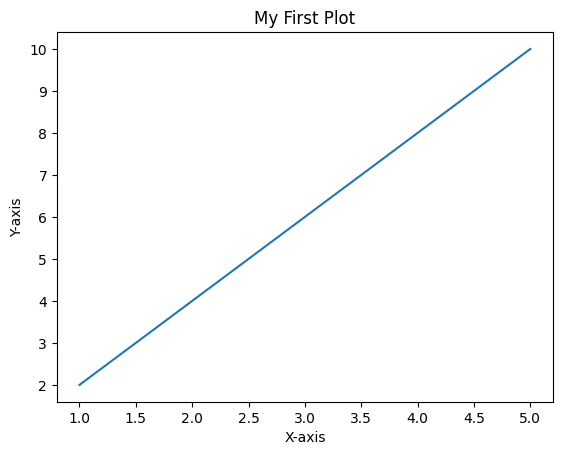

In [20]:
# Simplest possible plot
plt.plot([1, 2, 3, 4, 5], [2, 4, 6, 8, 10])
plt.title("My First Plot")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

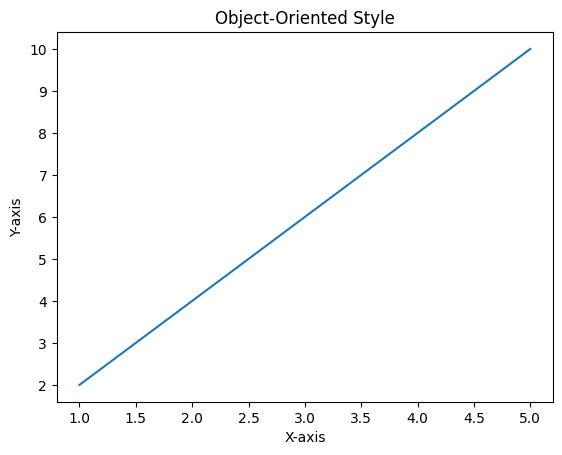

In [21]:
# Object-oriented approach (recommended)
fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4, 5], [2, 4, 6, 8, 10])
ax.set_title("Object-Oriented Style")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
plt.show()

## 2. Line Plots

Line plots are ideal for showing **trends over time** or continuous data.

### Common Parameters:
| Parameter | Description |
|-----------|-------------|
| `color` | Line color ('r', 'blue', '#FF5733') |
| `linewidth` / `lw` | Thickness of line |
| `linestyle` / `ls` | Style: '-', '--', ':', '-.' |
| `marker` | Data point marker: 'o', 's', '^', 'D' |
| `label` | Legend label |

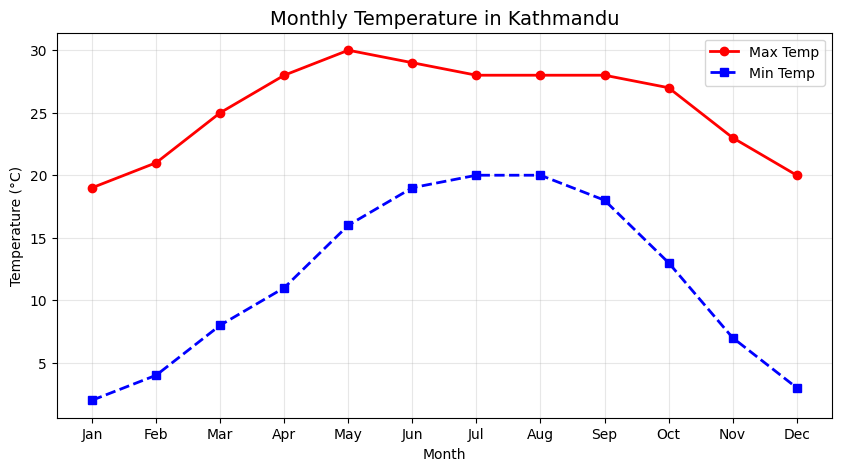

In [5]:
# Monthly temperature data for Kathmandu
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
max_temp = [19, 21, 25, 28, 30, 29, 28, 28, 28, 27, 23, 20]
min_temp = [2, 4, 8, 11, 16, 19, 20, 20, 18, 13, 7, 3]

plt.figure(figsize=(10, 5))
plt.plot(months, max_temp, color='red', marker='o', linewidth=2, label='Max Temp')
plt.plot(months, min_temp, color='blue', marker='s', linewidth=2, linestyle='--', label='Min Temp')

plt.title("Monthly Temperature in Kathmandu", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

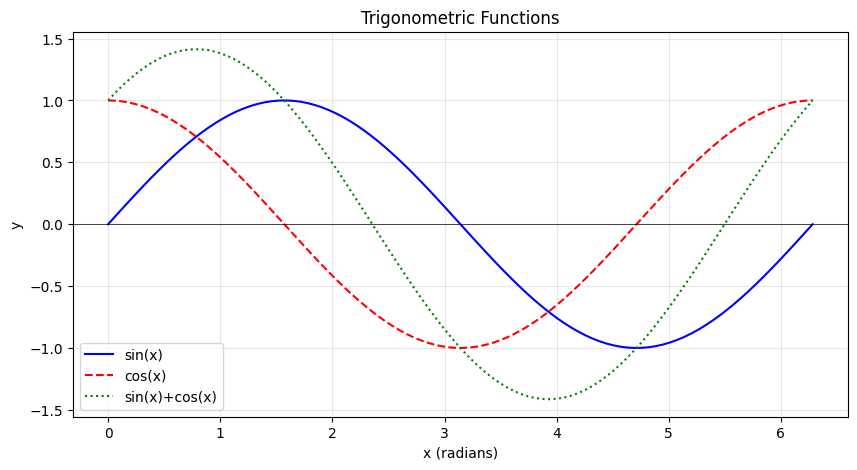

In [6]:
# Plotting mathematical functions
x = np.linspace(0, 2 * np.pi, 100)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, np.sin(x), label='sin(x)', color='blue')
ax.plot(x, np.cos(x), label='cos(x)', color='red', linestyle='--')
ax.plot(x, np.sin(x) + np.cos(x), label='sin(x)+cos(x)', color='green', linestyle=':')

ax.set_title("Trigonometric Functions")
ax.set_xlabel("x (radians)")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)
plt.show()

## 3. Bar Charts

Bar charts are best for **comparing categories**.

| Function | Description |
|----------|-------------|
| `plt.bar()` | Vertical bars |
| `plt.barh()` | Horizontal bars |
| `width` | Bar width (default 0.8) |

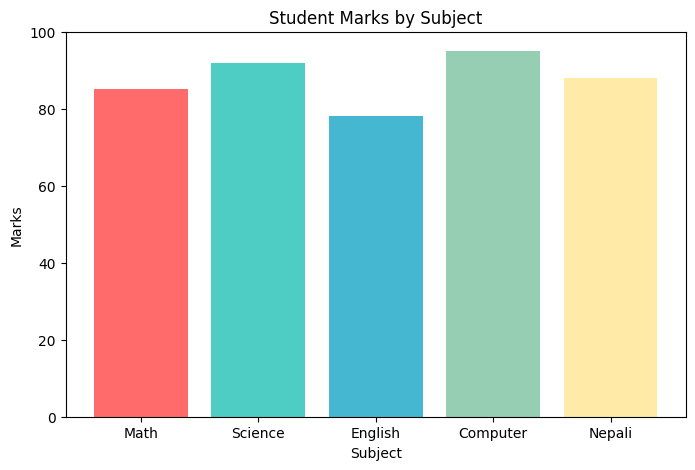

In [7]:
# Simple bar chart
subjects = ['Math', 'Science', 'English', 'Computer', 'Nepali']
marks = [85, 92, 78, 95, 88]

plt.figure(figsize=(8, 5))
bars = plt.bar(subjects, marks, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
plt.title("Student Marks by Subject")
plt.xlabel("Subject")
plt.ylabel("Marks")
plt.ylim(0, 100)

plt.show()

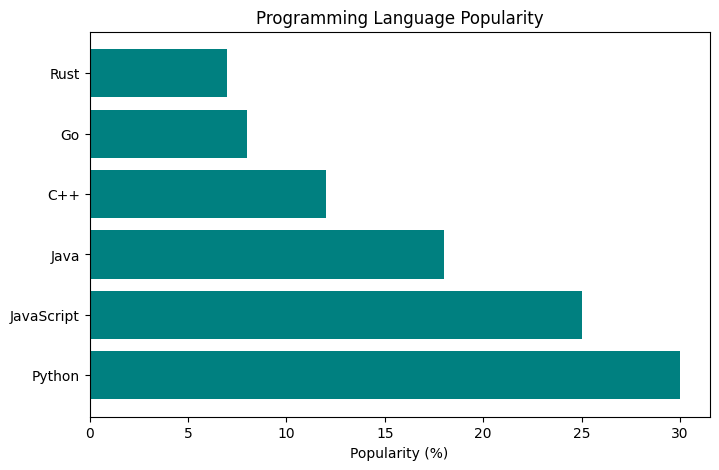

In [8]:
# Horizontal bar chart
languages = ['Python', 'JavaScript', 'Java', 'C++', 'Go', 'Rust']
popularity = [30, 25, 18, 12, 8, 7]

plt.figure(figsize=(8, 5))
plt.barh(languages, popularity, color='teal')
plt.title("Programming Language Popularity")
plt.xlabel("Popularity (%)")
plt.show()

## 4. Histograms

Histograms show the **distribution** of numerical data by grouping values into bins.

| Parameter | Description |
|-----------|-------------|
| `bins` | Number of bins (default 10) |
| `edgecolor` | Border color of bars |
| `alpha` | Transparency (0-1) |
| `density` | Normalize to probability density |

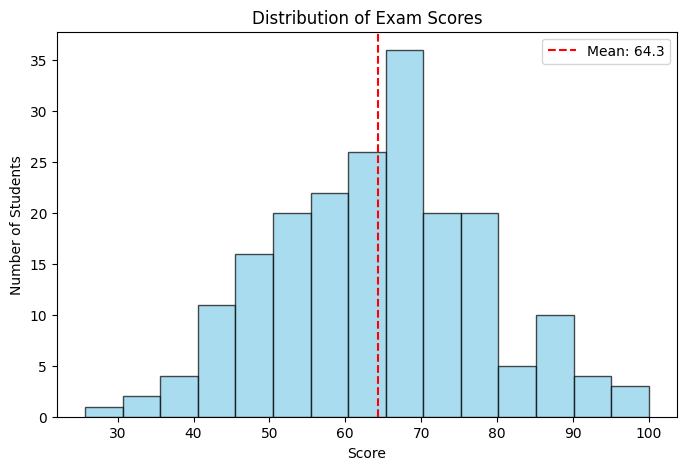

In [9]:
# Generate random exam scores
np.random.seed(42)
scores = np.random.normal(loc=65, scale=15, size=200)
scores = np.clip(scores, 0, 100)  # Keep between 0 and 100

plt.figure(figsize=(8, 5))
plt.hist(scores, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribution of Exam Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.axvline(scores.mean(), color='red', linestyle='--', label=f'Mean: {scores.mean():.1f}')
plt.legend()
plt.show()

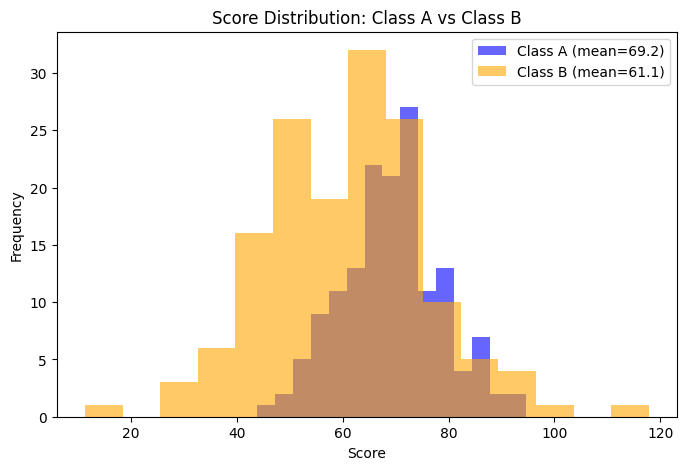

In [10]:
# Comparing two distributions
np.random.seed(42)
class_a = np.random.normal(70, 10, 150)
class_b = np.random.normal(60, 15, 150)

plt.figure(figsize=(8, 5))
plt.hist(class_a, bins=15, alpha=0.6, label=f'Class A (mean={class_a.mean():.1f})', color='blue')
plt.hist(class_b, bins=15, alpha=0.6, label=f'Class B (mean={class_b.mean():.1f})', color='orange')
plt.title("Score Distribution: Class A vs Class B")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## 5. Scatter Plots

Scatter plots show the **relationship between two numerical variables**.

| Parameter | Description |
|-----------|-------------|
| `s` | Marker size |
| `c` | Color (can be array for colormap) |
| `cmap` | Colormap name |
| `alpha` | Transparency |
| `marker` | Marker shape |

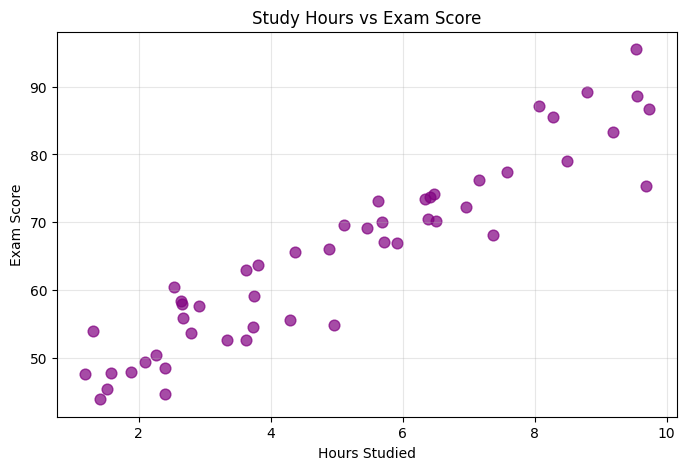

In [11]:
# Study hours vs exam score
np.random.seed(42)
hours_studied = np.random.uniform(1, 10, 50)
exam_score = 40 + 5 * hours_studied + np.random.normal(0, 5, 50)

plt.figure(figsize=(8, 5))
plt.scatter(hours_studied, exam_score, color='purple', alpha=0.7, s=60)
plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.grid(True, alpha=0.3)
plt.show()

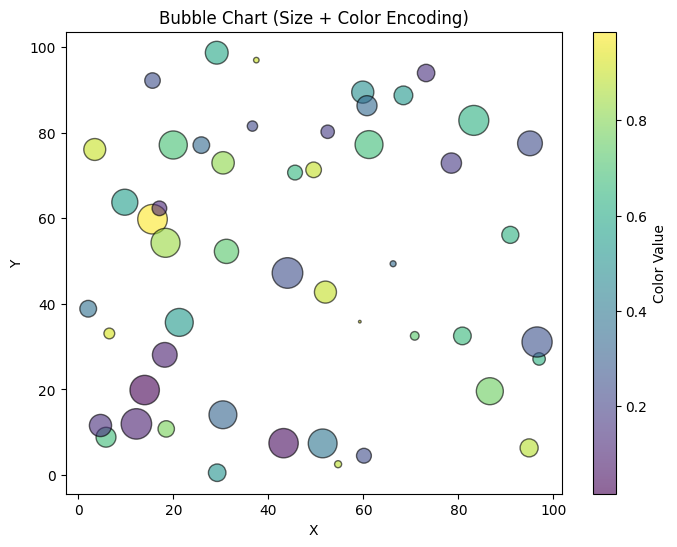

In [12]:
# Scatter plot with size and color encoding
np.random.seed(42)
n = 50
x = np.random.rand(n) * 100
y = np.random.rand(n) * 100
sizes = np.random.rand(n) * 500
colors = np.random.rand(n)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(x, y, s=sizes, c=colors, cmap='viridis', alpha=0.6, edgecolors='black')
plt.colorbar(scatter, label='Color Value')
plt.title("Bubble Chart (Size + Color Encoding)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## 6. Pie Charts

Pie charts show **proportions** of a whole. Use sparingly — bar charts are often clearer.

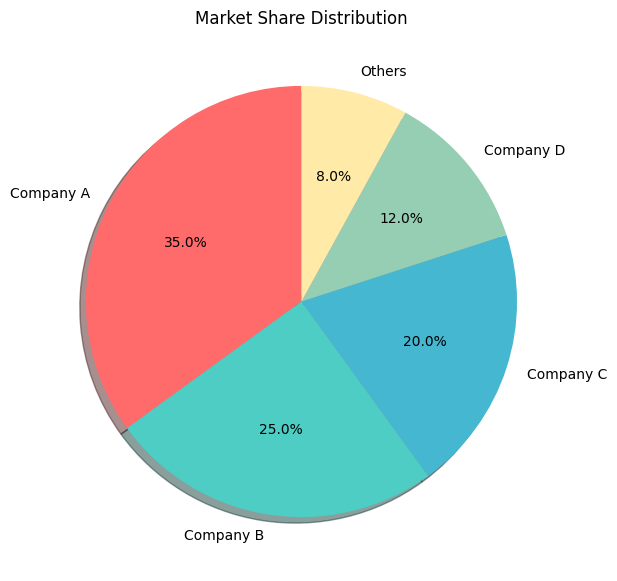

In [ ]:
# Market share
companies = ['Company A', 'Company B', 'Company C', 'Company D', 'Others']
market_share = [35, 25, 20, 12, 8]

plt.figure(figsize=(7, 7))
plt.pie(market_share, labels=companies, autopct='%1.1f%%', 
         shadow=True, startangle=90,
        colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
plt.title("Market Share Distribution")
plt.show()

## 7. Subplots

Subplots let you display **multiple plots in one figure**.

```python
fig, axes = plt.subplots(nrows, ncols, figsize=(w, h))
```

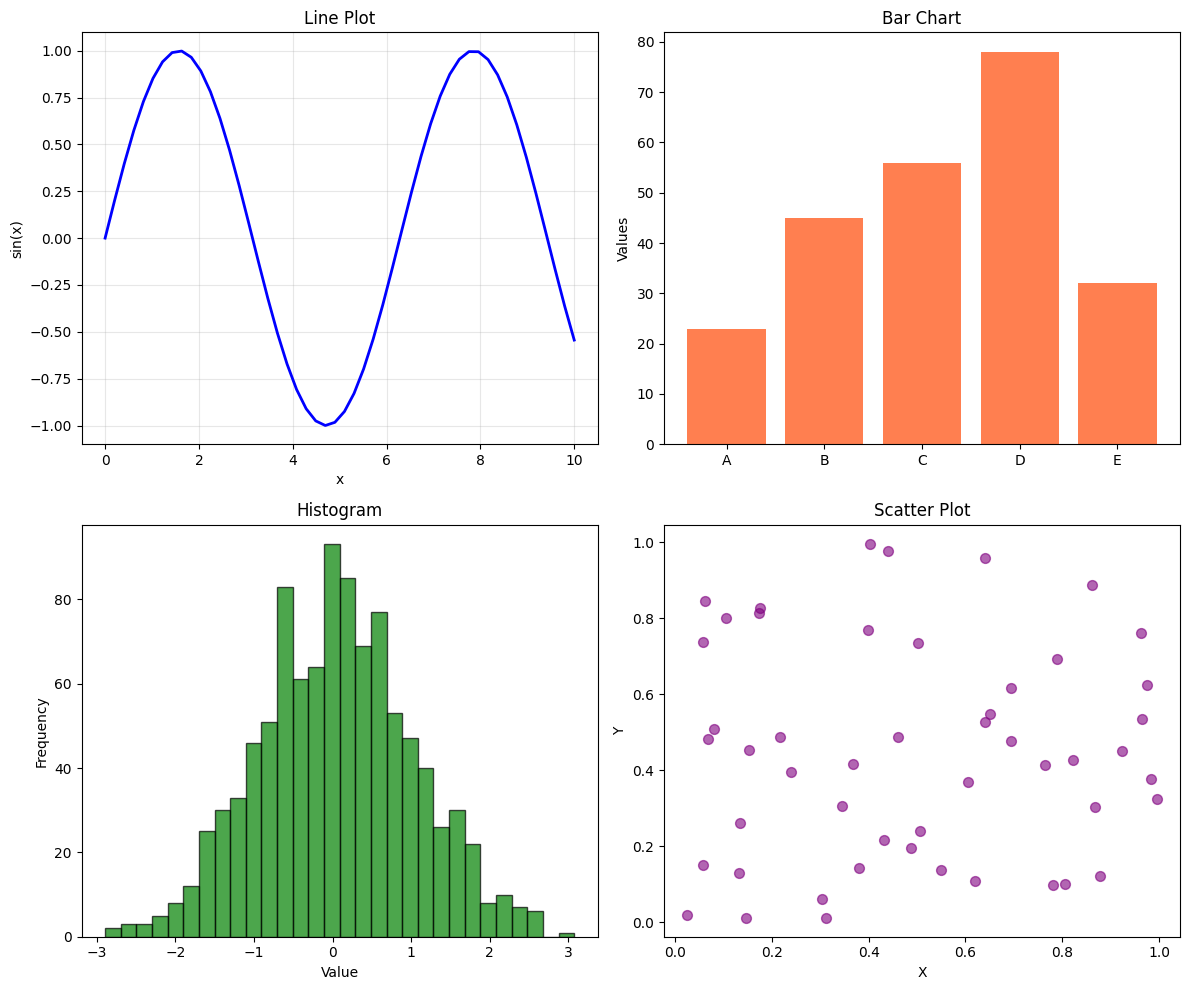

In [19]:
# 2x2 grid of different plot types
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Line plot
x = np.linspace(0, 10, 50)
axes[0, 0].plot(x, np.sin(x), 'b-', linewidth=2)
axes[0, 0].set_title("Line Plot")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("sin(x)")
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Bar chart
categories = ['A', 'B', 'C', 'D', 'E']
values = [23, 45, 56, 78, 32]
axes[0, 1].bar(categories, values, color='coral')
axes[0, 1].set_title("Bar Chart")
axes[0, 1].set_ylabel("Values")

# Plot 3: Histogram
data = np.random.randn(1000)
axes[1, 0].hist(data, bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_title("Histogram")
axes[1, 0].set_xlabel("Value")
axes[1, 0].set_ylabel("Frequency")

# Plot 4: Scatter plot
x_scatter = np.random.rand(50)
y_scatter = np.random.rand(50)
axes[1, 1].scatter(x_scatter, y_scatter, c='purple', alpha=0.6, s=50)
axes[1, 1].set_title("Scatter Plot")
axes[1, 1].set_xlabel("X")
axes[1, 1].set_ylabel("Y")

plt.tight_layout()
plt.show()

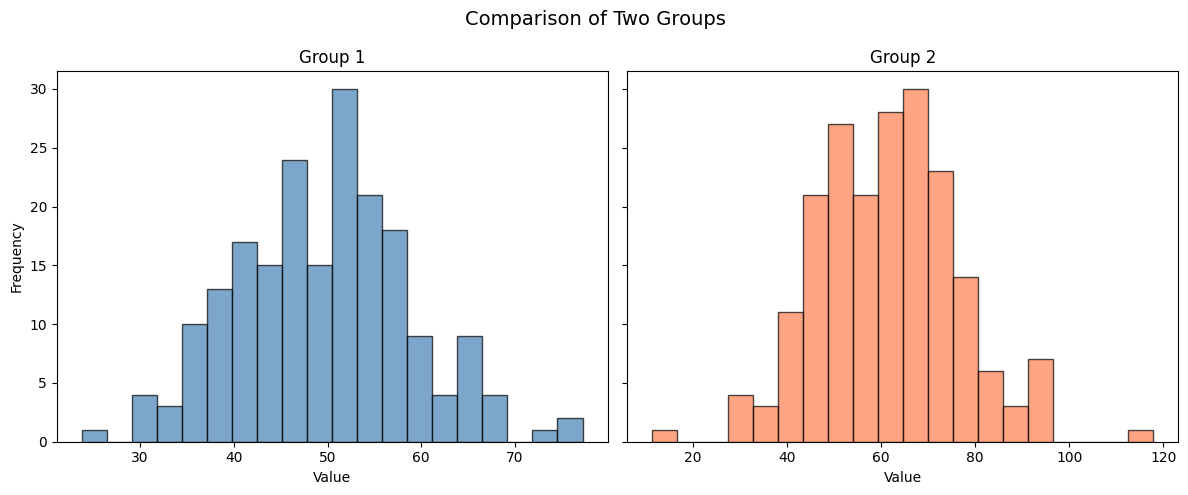

In [15]:
# Subplots with shared axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

np.random.seed(42)
data1 = np.random.normal(50, 10, 200)
data2 = np.random.normal(60, 15, 200)

ax1.hist(data1, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_title("Group 1")
ax1.set_xlabel("Value")
ax1.set_ylabel("Frequency")

ax2.hist(data2, bins=20, color='coral', edgecolor='black', alpha=0.7)
ax2.set_title("Group 2")
ax2.set_xlabel("Value")

plt.suptitle("Comparison of Two Groups", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Saving Figures

Save your plots as image files using `fig.savefig()`.

Plot saved as 'sample_plot.png'


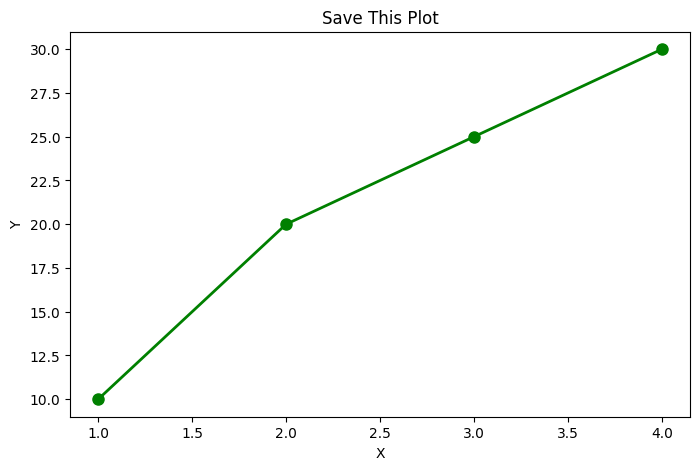

In [16]:
# Saving figures
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([1, 2, 3, 4], [10, 20, 25, 30], 'go-', linewidth=2, markersize=8)
ax.set_title("Save This Plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# Save as PNG and PDF
fig.savefig('sample_plot.png', dpi=150, bbox_inches='tight')
print("Plot saved as 'sample_plot.png'")
plt.show()

## 9. Practice: Visualizing Real Data

Let's create a comprehensive visualization using student data.

In [17]:
# Create sample student dataset
np.random.seed(42)
n_students = 100

students = pd.DataFrame({
    'Name': [f'Student_{i}' for i in range(1, n_students + 1)],
    'Math': np.random.randint(40, 100, n_students),
    'Science': np.random.randint(35, 100, n_students),
    'English': np.random.randint(45, 100, n_students),
    'Computer': np.random.randint(50, 100, n_students),
    'Hours_Studied': np.random.uniform(1, 8, n_students)
})

students['Average'] = students[['Math', 'Science', 'English', 'Computer']].mean(axis=1)
students.head(10)

,Name,Math,Science,English,Computer,Hours_Studied,Average
0,Student_1,78,96,99,70,3.629081,85.75
1,Student_2,91,74,48,97,1.657874,77.50
2,Student_3,68,87,99,69,5.047961,80.75
3,Student_4,54,58,55,57,1.251596,56.00
4,Student_5,82,60,61,56,4.259186,64.75
5,Student_6,47,94,82,52,4.798512,68.75
6,Student_7,60,75,68,66,3.005789,67.25
7,Student_8,78,63,49,82,5.135833,68.00
8,Student_9,97,49,96,97,1.213502,84.75
9,Student_10,58,79,78,61,1.261437,69.00


C:\Users\ACER\AppData\Local\Temp\ipykernel_68756\2444406820.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 2].boxplot([students['Math'], students['Science'], students['English'], students['Computer']],


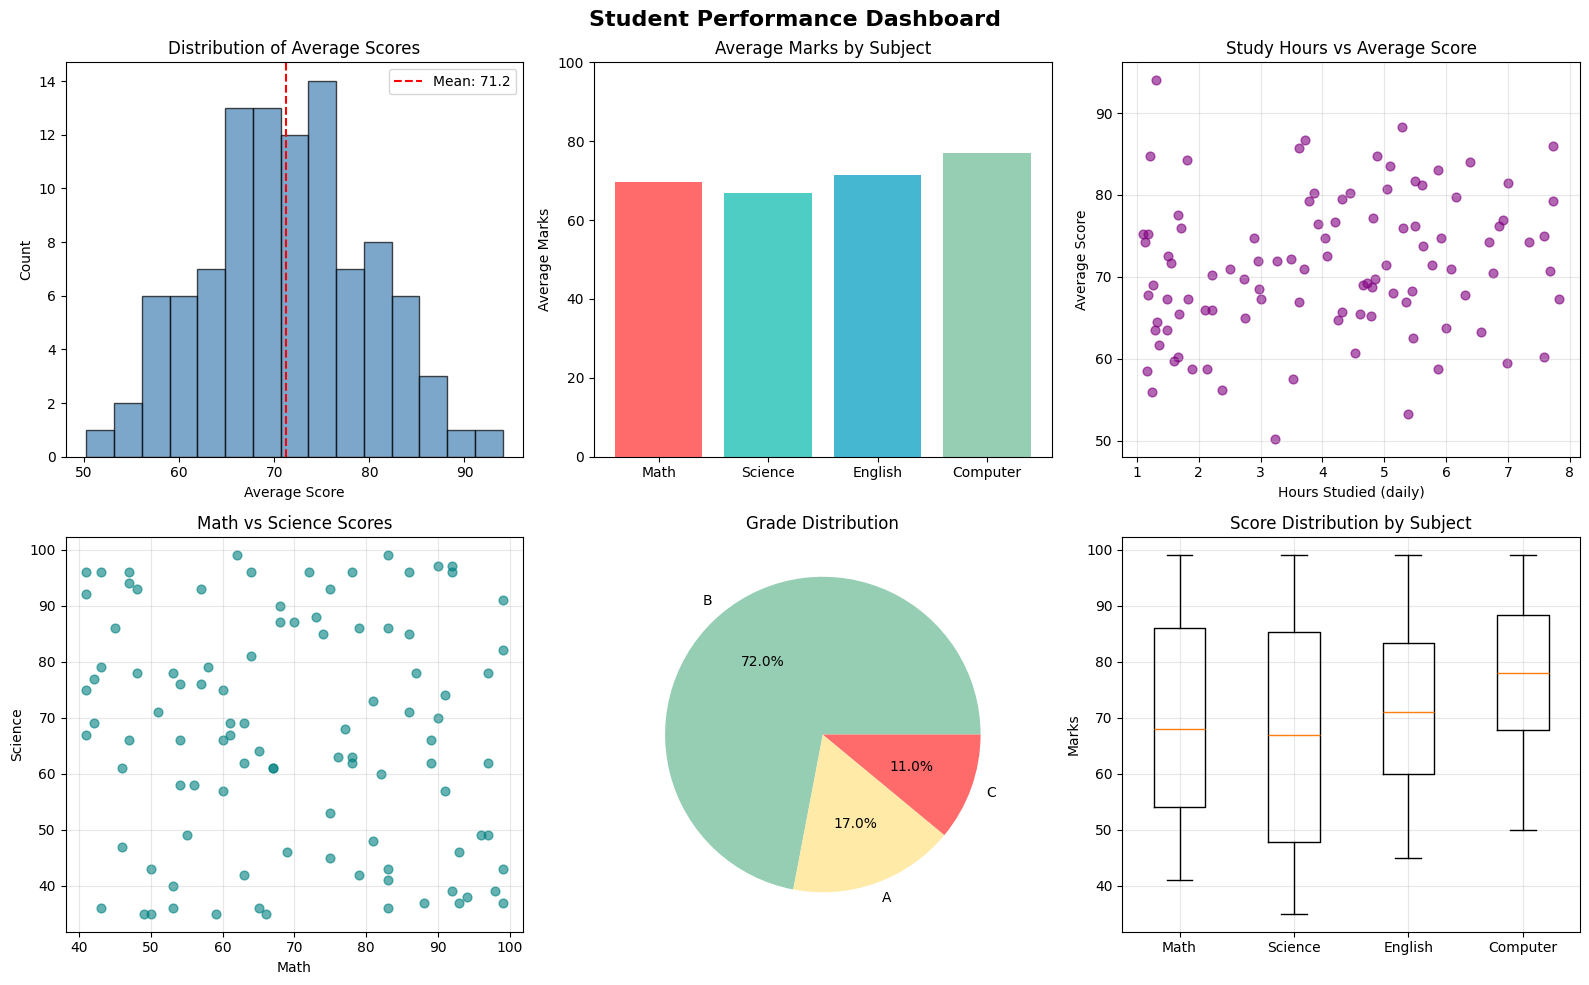

In [18]:
# Comprehensive dashboard
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Student Performance Dashboard", fontsize=16, fontweight='bold')

# 1. Distribution of average scores
axes[0, 0].hist(students['Average'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(students['Average'].mean(), color='red', linestyle='--', label=f"Mean: {students['Average'].mean():.1f}")
axes[0, 0].set_title("Distribution of Average Scores")
axes[0, 0].set_xlabel("Average Score")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# 2. Subject-wise average marks (bar chart)
subjects = ['Math', 'Science', 'English', 'Computer']
avg_marks = [students[sub].mean() for sub in subjects]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
axes[0, 1].bar(subjects, avg_marks, color=colors)
axes[0, 1].set_title("Average Marks by Subject")
axes[0, 1].set_ylabel("Average Marks")
axes[0, 1].set_ylim(0, 100)

# 3. Hours studied vs Average score (scatter)
axes[0, 2].scatter(students['Hours_Studied'], students['Average'], 
                   alpha=0.6, color='purple', s=40)
axes[0, 2].set_title("Study Hours vs Average Score")
axes[0, 2].set_xlabel("Hours Studied (daily)")
axes[0, 2].set_ylabel("Average Score")
axes[0, 2].grid(True, alpha=0.3)

# 4. Math vs Science correlation
axes[1, 0].scatter(students['Math'], students['Science'], alpha=0.6, color='teal', s=40)
axes[1, 0].set_title("Math vs Science Scores")
axes[1, 0].set_xlabel("Math")
axes[1, 0].set_ylabel("Science")
axes[1, 0].grid(True, alpha=0.3)

# 5. Grade distribution (pie chart)
def get_grade(avg):
    if avg >= 80: return 'A'
    elif avg >= 60: return 'B'
    elif avg >= 40: return 'C'
    else: return 'D'

students['Grade'] = students['Average'].apply(get_grade)
grade_counts = students['Grade'].value_counts()
axes[1, 1].pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%',
              colors=['#96CEB4', '#FFEAA7', '#FF6B6B', '#DDA0DD'])
axes[1, 1].set_title("Grade Distribution")

# 6. Box plot of all subjects
axes[1, 2].boxplot([students['Math'], students['Science'], students['English'], students['Computer']],
                   labels=subjects)
axes[1, 2].set_title("Score Distribution by Subject")
axes[1, 2].set_ylabel("Marks")
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()